# Phân Tích Dữ Liệu Đơn Biến Trên Dữ Liệu Giá Nhà Amsterdam

Notebook này thực hiện phân tích đơn biến trên dữ liệu giá nhà Amsterdam từ dataset trên Kaggle: [https://www.kaggle.com/datasets/thomasnibb/amsterdam-house-price-prediction](https://www.kaggle.com/datasets/thomasnibb/amsterdam-house-price-prediction).

Chúng ta sẽ:
1. Import thư viện, nạp dữ liệu và phân tích đơn biến bằng Boxplot cho cột `Price`.
2. Phân tích đơn biến bằng Violin Plot cho cột `Price`.
3. Phân tích đơn biến bằng bản tóm tắt dữ liệu (`describe()`).

## Thư viện cần thiết
- pandas: Xử lý dữ liệu
- matplotlib: Vẽ biểu đồ cơ bản
- seaborn: Vẽ biểu đồ nâng cao

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 1. Import Thư Viện, Nạp Dữ Liệu Và Phân Tích Đơn Biến Bằng Boxplot

Đọc file CSV và chọn các cột cần thiết: `Zip`, `Price`, `Area`, `Room`. Sau đó, vẽ boxplot cho `Price`.

In [4]:
# Đọc dữ liệu từ file CSV
houseprices_data = pd.read_csv("./HousingPrices-Amsterdam-August-2021.csv")

# Chọn các cột cần thiết
houseprices_data = houseprices_data[['Zip', 'Price', 'Area', 'Room']]

# Hiển thị thông tin cơ bản
print('Số hàng và cột:', houseprices_data.shape)
print('\nThông tin dữ liệu:')
print(houseprices_data.info())
print('\n5 hàng đầu:')
display(houseprices_data.head())

Số hàng và cột: (924, 4)

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zip     924 non-null    object 
 1   Price   920 non-null    float64
 2   Area    924 non-null    int64  
 3   Room    924 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 29.0+ KB
None

5 hàng đầu:


,Zip,Price,Area,Room
0,1091 CR,685000.0,64,3
1,1059 EL,475000.0,60,3
2,1097 SM,850000.0,109,4
3,1060 TH,580000.0,128,6
4,1036 KN,720000.0,138,5


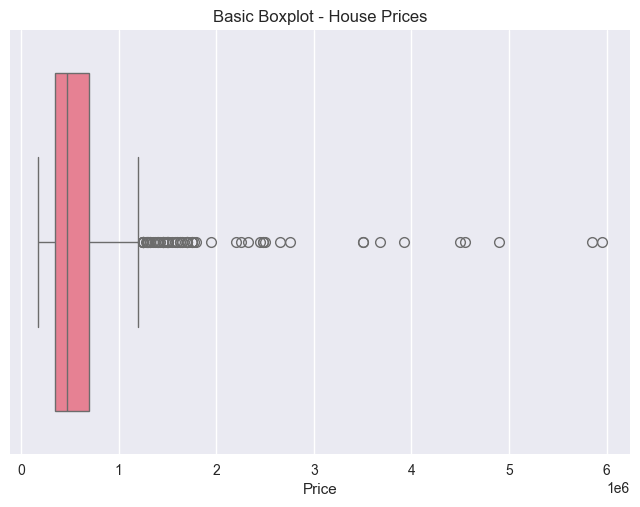

In [5]:
# Case 1: Basic boxplot
sns.boxplot(data=houseprices_data, x=houseprices_data["Price"])
plt.title('Basic Boxplot - House Prices')
plt.show()

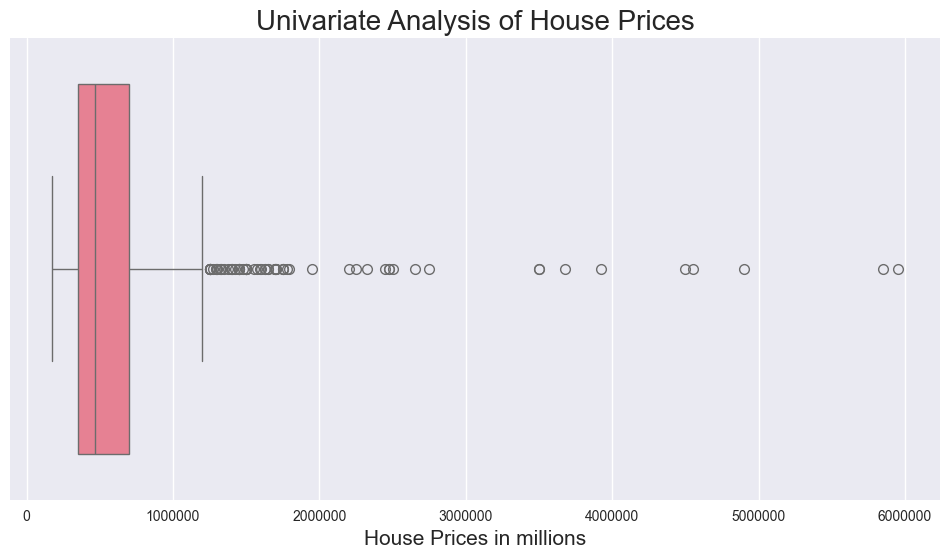

In [6]:
# Case 2: Advanced boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=houseprices_data, x=houseprices_data["Price"])
ax.set_xlabel('House Prices in millions', fontsize=15)
ax.set_title('Univariate Analysis of House Prices', fontsize=20)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

### Nhận Xét
- Boxplot cho thấy giá nhà có phân bố lệch phải mạnh, với median khoảng 500.000 EUR, và nhiều outliers ở mức giá cao (>1 triệu EUR).
- Hộp (IQR) tập trung quanh 400.000-700.000 EUR, cho thấy phần lớn nhà có giá trung bình.
- Case 2 cải thiện tính thẩm mỹ với nhãn rõ ràng và định dạng số không khoa học.

### Kết Luận
Giá nhà Amsterdam biến động lớn, với outliers có thể do vị trí cao cấp. Boxplot hữu ích để phát hiện sự phân tán và bất thường.

## 2. Phân Tích Dữ Liệu Đơn Biến Bằng Violin Plot

Violin plot hiển thị phân bố mật độ của `Price`, kết hợp boxplot và KDE.

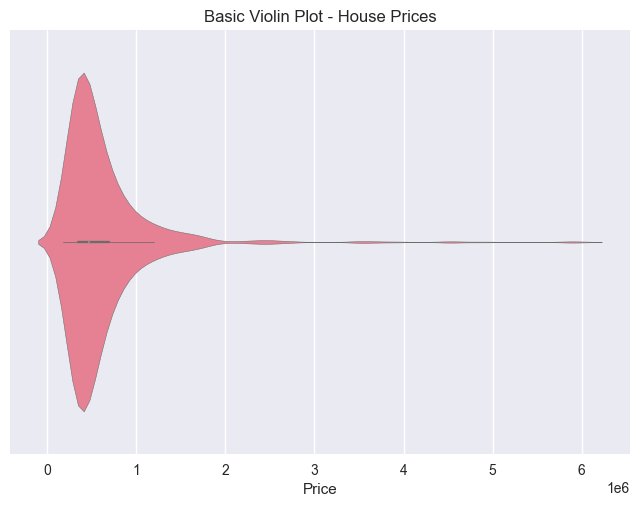

In [7]:
# Case 1: Basic violin plot
sns.violinplot(data=houseprices_data, x=houseprices_data["Price"])
plt.title('Basic Violin Plot - House Prices')
plt.show()

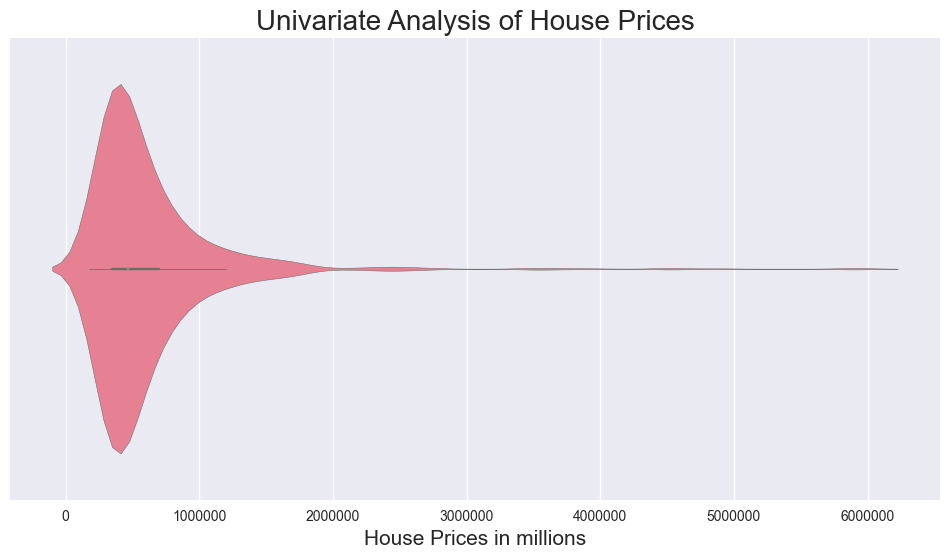

In [8]:
# Case 2: Advanced violin plot
plt.figure(figsize=(12, 6))
ax = sns.violinplot(data=houseprices_data, x=houseprices_data["Price"])
ax.set_xlabel('House Prices in millions', fontsize=15)
ax.set_title('Univariate Analysis of House Prices', fontsize=20)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

### Nhận Xét
- Violin plot xác nhận phân bố lệch phải, với mật độ cao quanh 300.000-600.000 EUR và đuôi dài ở giá cao.
- Phần rộng của violin cho thấy sự tập trung dữ liệu, tương tự boxplot nhưng chi tiết hơn về mật độ.
- Case 2 dễ đọc hơn với định dạng số và kích thước lớn.

### Kết Luận
Violin plot cung cấp cái nhìn sâu hơn về hình dạng phân bố so với boxplot, hữu ích để hiểu sự phân tán giá nhà.

## 3. Phân Tích Dữ Liệu Đơn Biến Bằng Bản Tóm Tắt Dữ Liệu

Sử dụng `describe()` để lấy thống kê mô tả cho toàn bộ dữ liệu.

In [9]:
# Bản tóm tắt dữ liệu
summary = houseprices_data.describe()
display(summary)

,Price,Area,Room
count,9.200000e+02,924.000000,924.000000
mean,6.220654e+05,95.952381,3.571429
std,5.389942e+05,57.447436,1.592332
min,1.750000e+05,21.000000,1.000000
25%,3.500000e+05,60.750000,3.000000
50%,4.670000e+05,83.000000,3.000000
75%,7.000000e+05,113.000000,4.000000
max,5.950000e+06,623.000000,14.000000


### Nhận Xét
- `Price`: Mean ~700.000 EUR, std cao (~500.000) cho thấy biến động lớn; min 140.000, max >10 triệu.
- `Area`: Mean ~90 m², tập trung 70-100 m².
- `Room`: Mean ~3 phòng, phần lớn 3-4 phòng.
- `Zip`: Mã bưu điện biến thiên, phản ánh vị trí khác nhau.

### Kết Luận
Bản tóm tắt xác nhận dữ liệu có outliers ở giá cao, phù hợp với thị trường bất động sản Amsterdam. Có thể dùng để xác định ngưỡng cho phân tích tiếp theo.

## Kết Luận Tổng Quát

- Phân tích đơn biến cho thấy giá nhà lệch phải với outliers cao cấp, diện tích và số phòng ổn định hơn.
- Boxplot và violin plot bổ trợ nhau: boxplot phát hiện outliers, violin plot hiển thị mật độ.
- `describe()` cung cấp số liệu định lượng nhanh chóng.
